In [1]:
import pandas as pd
import numpy as np
import tensorflow
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
df = pd.read_csv("creditcard.csv")
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [6]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [7]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [8]:
df['Hour'] = (df['Time'] // 3600) % 24
df = df.drop('Time', axis=1)

In [9]:
df

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Hour
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,0.0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0.0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0.0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,...,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0,23.0
284803,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,...,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0,23.0
284804,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,...,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0,23.0
284805,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,...,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0,23.0


In [10]:
x = df.drop('Class', axis=1)
y = df['Class']

In [23]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [24]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [13]:
base_modell = Sequential()
base_modell.add(Dense(16,activation='relu',input_dim=x_train_scaled.shape[1]))
base_modell.add(Dense(8,activation='relu'))
base_modell.add(Dense(1,activation='sigmoid'))
base_modell.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy','precision','recall'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
from keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss',patience=5,verbose=1)
history = base_modell.fit(x_train_scaled,y_train,epochs=100,validation_split=0.2,callbacks=[early_stop])

Epoch 1/100
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 30s 5ms/step - accuracy: 0.9986 - loss: 0.0105 - precision: 0.5695 - recall: 0.6764 - val_accuracy: 0.9994 - val_loss: 0.0034 - val_precision: 0.8519 - val_recall: 0.8118
Epoch 2/100
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - accuracy: 0.9994 - loss: 0.0032 - precision: 0.8796 - recall: 0.7799 - val_accuracy: 0.9993 - val_loss: 0.0030 - val_precision: 0.8046 - val_recall: 0.8235
Epoch 3/100
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 54s 6ms/step - accuracy: 0.9994 - loss: 0.0029 - precision: 0.8736 - recall: 0.7605 - val_accuracy: 0.9994 - val_loss: 0.0029 - val_precision: 0.8452 - val_recall: 0.8353
Epoch 4/100
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.9994 - loss: 0.0027 - precision: 0.8582 - recall: 0.7638 - val_accuracy: 0.9994 - val_loss: 0.0030 - val_precision: 0.8519 - val_recall: 0.8118
Epoch 5/100
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.9994 - loss: 0.0026 - precision: 0.8718 - recall: 0.7702 - val_accuracy: 0

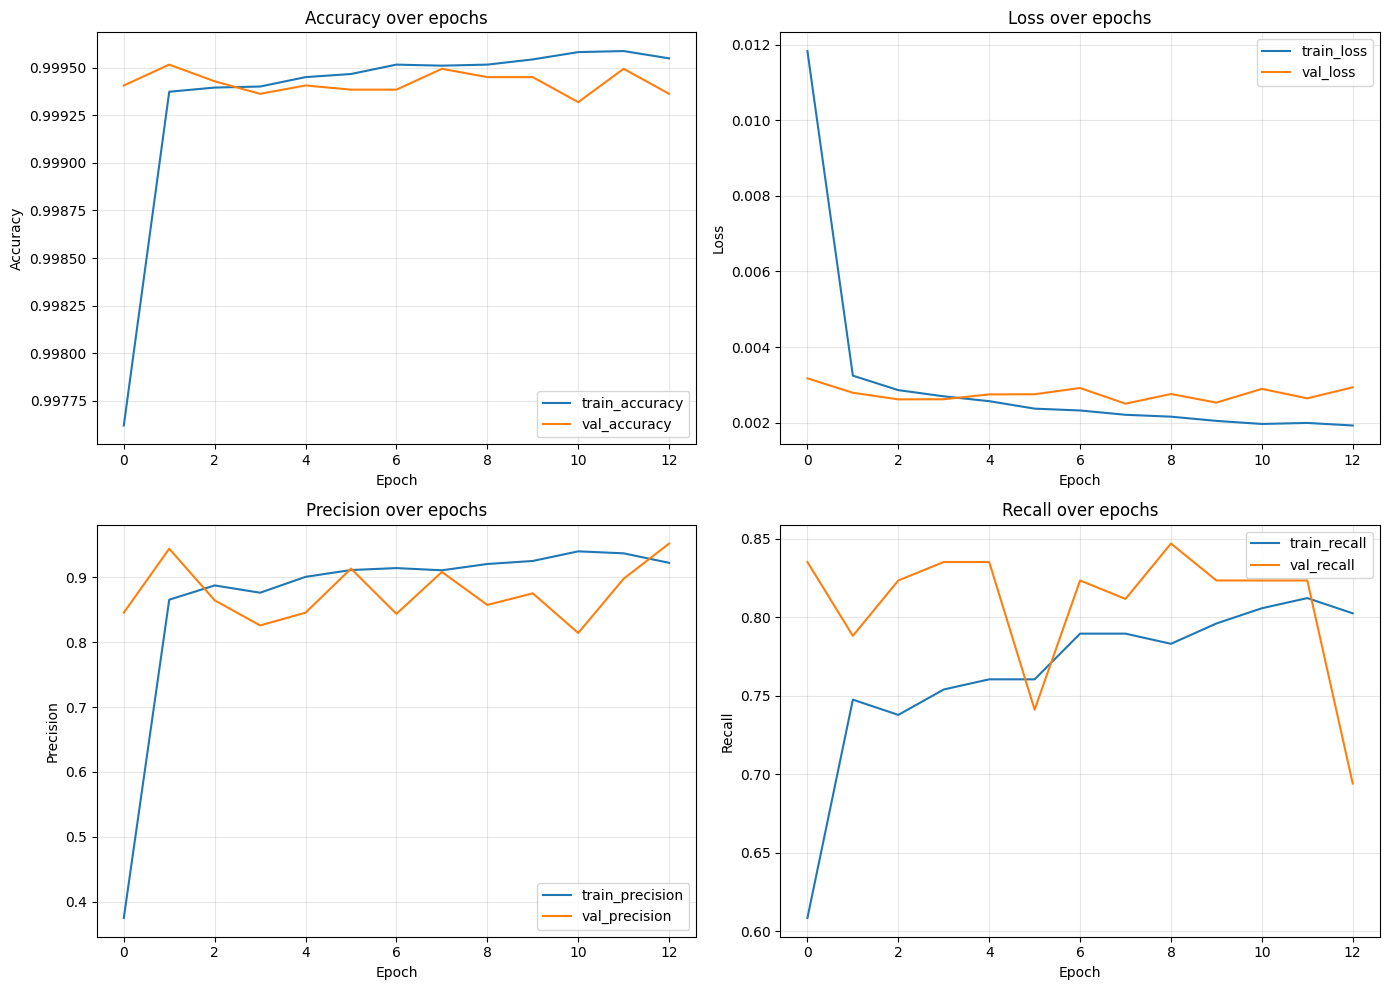

In [19]:
import matplotlib.pyplot as plt

metrics = ['accuracy', 'loss', 'precision', 'recall']

plt.figure(figsize=(14, 10))

for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    plt.plot(history.history[metric], label=f'train_{metric}')
    plt.plot(history.history[f'val_{metric}'], label=f'val_{metric}')
    plt.title(f'{metric.capitalize()} over epochs')
    plt.xlabel('Epoch')
    plt.ylabel(metric.capitalize())
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

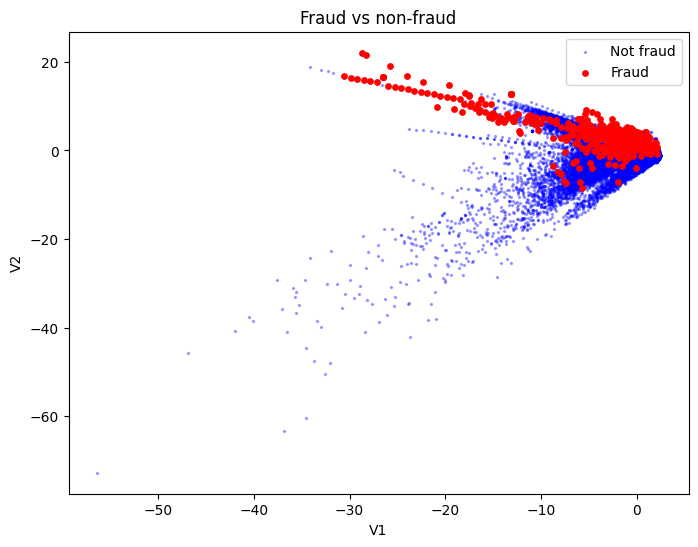

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(df[df['Class']==0]['V1'], df[df['Class']==0]['V2'],
            s=2, c='blue', alpha=0.3, label='Not fraud')
plt.scatter(df[df['Class']==1]['V1'], df[df['Class']==1]['V2'],
            s=15, c='red', label='Fraud')
plt.xlabel('V1')
plt.ylabel('V2')
plt.title('Fraud vs non-fraud')
plt.legend()
plt.show()

In [15]:
from imblearn.over_sampling import SMOTE
X_Train,X_Test,Y_train,Y_test = train_test_split(x,y,test_size=0.2,random_state=42)

#scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_Train)
X_test_scaled = scaler.transform(X_Test)

#applying smote
smote = SMOTE(random_state=42)
x_resampled_smote,y_resampled_smote = smote.fit_resample(X_train_scaled,Y_train)

AttributeError: 'numpy.ndarray' object has no attribute 'iloc'

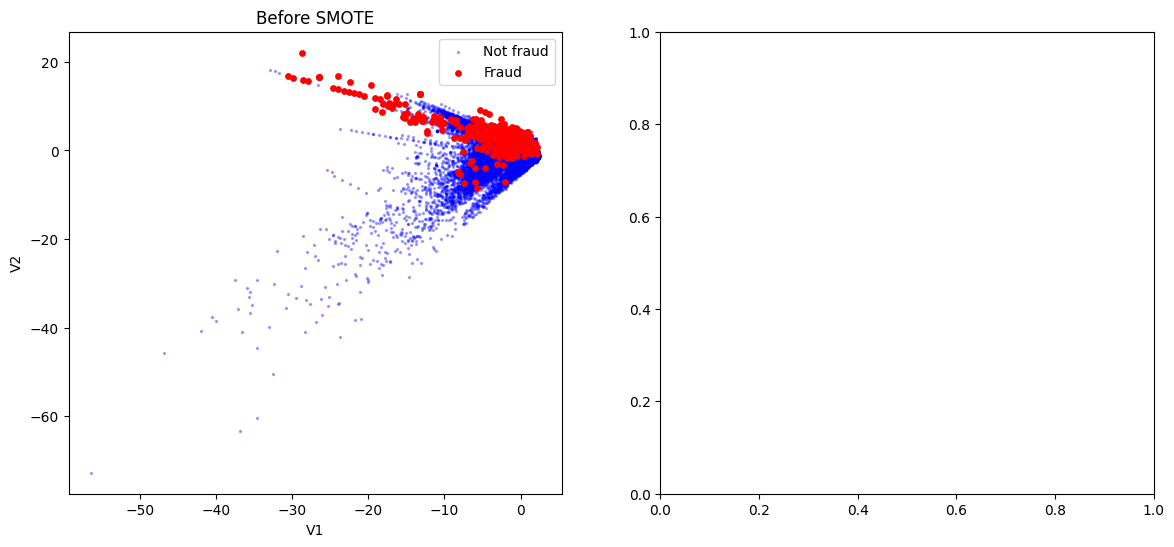

In [26]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_train[Y_train==0].iloc[:, 0], X_train[Y_train==0].iloc[:, 1],
                s=2, c='blue', alpha=0.3, label='Not fraud')
axes[0].scatter(X_train[Y_train==1].iloc[:, 0], X_train[Y_train==1].iloc[:, 1],
                s=15, c='red', label='Fraud')
axes[0].set_title('Before SMOTE')
axes[0].set_xlabel('V1')
axes[0].set_ylabel('V2')
axes[0].legend()

axes[1].scatter(x_resampled_smote[y_resampled_smote==0].iloc[:, 0], x_resampled_smote[y_resampled_smote==0].iloc[:, 1],
                s=2, c='blue', alpha=0.3, label='Not fraud')
axes[1].scatter(x_resampled_smote[y_resampled_smote==1].iloc[:, 0], x_resampled_smote[y_resampled_smote==1].iloc[:, 1],
                s=2, c='red', alpha=0.3, label='Fraud (synthetic)')
axes[1].set_title('After SMOTE')
axes[1].set_xlabel('V1')
axes[1].set_ylabel('V2')
axes[1].legend()

plt.tight_layout()
plt.show()


In [16]:
model_smotee = Sequential()
model_smotee.add(Dense(16,activation='relu',input_dim=x_resampled_smote.shape[1]))
model_smotee.add(Dense(8,activation='relu'))
model_smotee.add(Dense(1,activation='sigmoid'))
model_smotee.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy','precision','recall'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, verbose=1)
history_smote = model_smotee.fit(
    x_resampled_smote, y_resampled_smote,
    validation_data=(X_test_scaled, Y_test),
    epochs=100,
    callbacks=[early_stop]
)

Epoch 1/100
14216/14216 ━━━━━━━━━━━━━━━━━━━━ 51s 3ms/step - accuracy: 0.9888 - loss: 0.0352 - precision: 0.9887 - recall: 0.9889 - val_accuracy: 0.9942 - val_loss: 0.0214 - val_precision: 0.2118 - val_recall: 0.8776
Epoch 2/100
14216/14216 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - accuracy: 0.9978 - loss: 0.0095 - precision: 0.9961 - recall: 0.9995 - val_accuracy: 0.9967 - val_loss: 0.0159 - val_precision: 0.3281 - val_recall: 0.8571
Epoch 3/100
14216/14216 ━━━━━━━━━━━━━━━━━━━━ 42s 3ms/step - accuracy: 0.9985 - loss: 0.0072 - precision: 0.9972 - recall: 0.9997 - val_accuracy: 0.9972 - val_loss: 0.0160 - val_precision: 0.3664 - val_recall: 0.8673
Epoch 4/100
14216/14216 ━━━━━━━━━━━━━━━━━━━━ 46s 3ms/step - accuracy: 0.9987 - loss: 0.0061 - precision: 0.9977 - recall: 0.9997 - val_accuracy: 0.9976 - val_loss: 0.0155 - val_precision: 0.4118 - val_recall: 0.8571
Epoch 5/100
14216/14216 ━━━━━━━━━━━━━━━━━━━━ 59s 4ms/step - accuracy: 0.9989 - loss: 0.0051 - precision: 0.9981 - recall: 0.9998 - val_a

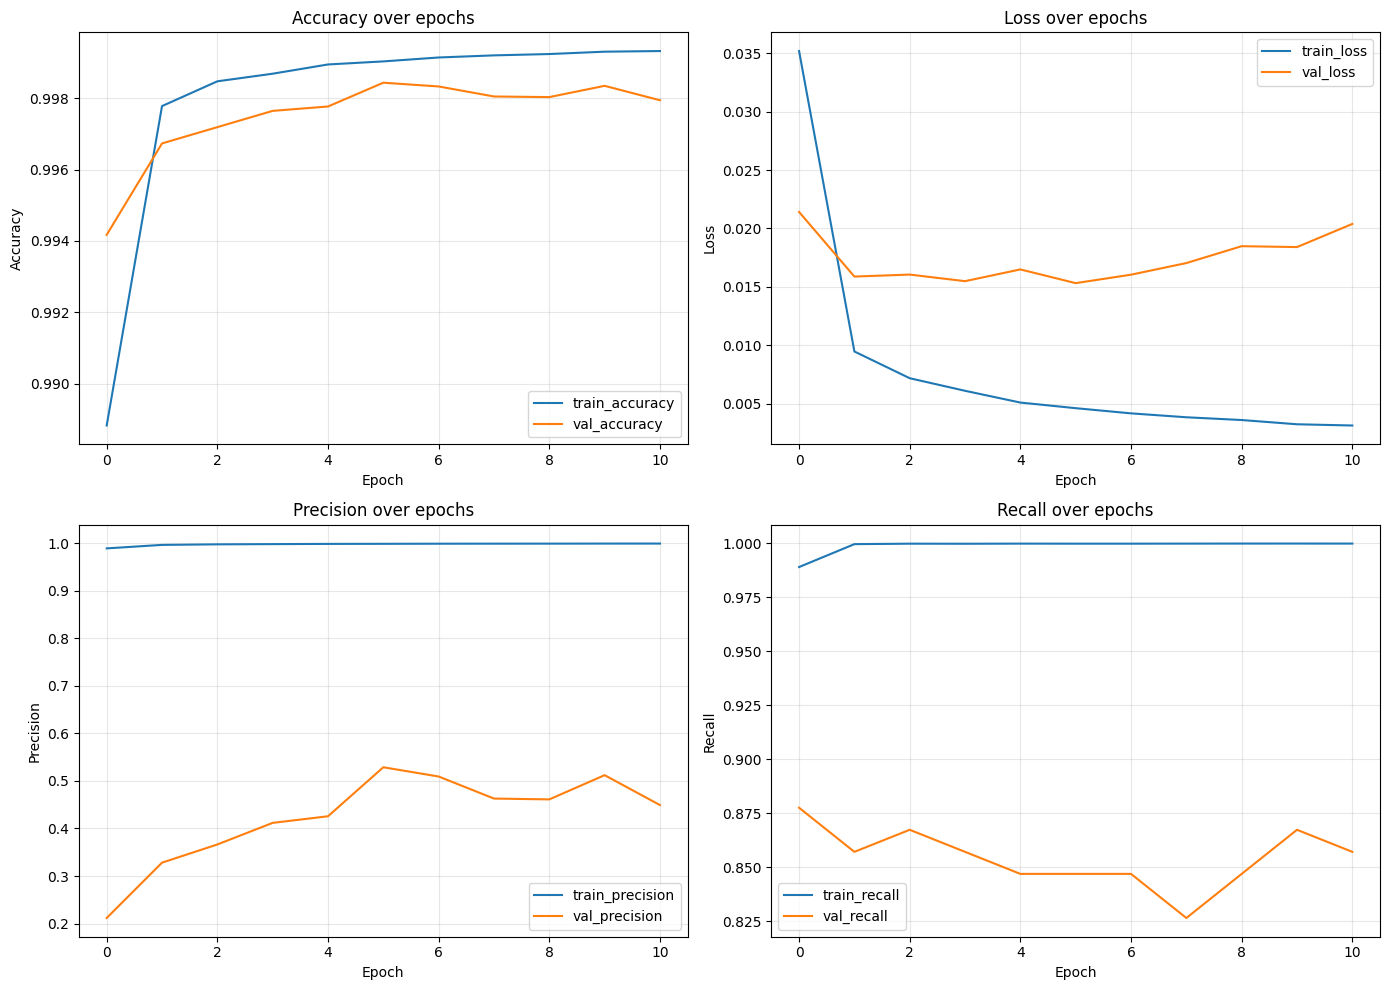

In [18]:
import matplotlib.pyplot as plt

metrics = ['accuracy', 'loss', 'precision', 'recall']

plt.figure(figsize=(14, 10))

for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    plt.plot(history_smote.history[metric], label=f'train_{metric}')
    plt.plot(history_smote.history[f'val_{metric}'], label=f'val_{metric}')
    plt.title(f'{metric.capitalize()} over epochs')
    plt.xlabel('Epoch')
    plt.ylabel(metric.capitalize())
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# **cost sensitive method**

In [25]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)

{0: np.float64(0.5008661206149896), 1: np.float64(289.14340101522845)}


In [28]:
class_weight_dict = {0: 1, 1: 20}

In [29]:
model_cost = Sequential()
model_cost.add(Dense(16, activation='relu', input_dim=X_train_scaled.shape[1]))
model_cost.add(Dense(8, activation='relu'))
model_cost.add(Dense(1, activation='sigmoid'))
model_cost.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy','precision','recall'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, verbose=1)
history_cost = model_cost.fit(
    X_train_scaled, Y_train,
    validation_data=(X_test_scaled, Y_test),
    epochs=100,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

Epoch 1/100
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - accuracy: 0.9983 - loss: 0.0525 - precision: 0.5085 - recall: 0.7614 - val_accuracy: 0.9990 - val_loss: 0.0087 - val_precision: 0.6535 - val_recall: 0.8469
Epoch 2/100
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 36s 3ms/step - accuracy: 0.9988 - loss: 0.0318 - precision: 0.6248 - recall: 0.8325 - val_accuracy: 0.9989 - val_loss: 0.0098 - val_precision: 0.6391 - val_recall: 0.8673
Epoch 3/100
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - accuracy: 0.9987 - loss: 0.0280 - precision: 0.5842 - recall: 0.8452 - val_accuracy: 0.9986 - val_loss: 0.0124 - val_precision: 0.5695 - val_recall: 0.8776
Epoch 4/100
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - accuracy: 0.9987 - loss: 0.0257 - precision: 0.5826 - recall: 0.8503 - val_accuracy: 0.9974 - val_loss: 0.0140 - val_precision: 0.3921 - val_recall: 0.9082
Epoch 5/100
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - accuracy: 0.9986 - loss: 0.0241 - precision: 0.5679 - recall: 0.8706 - val_accuracy: 0

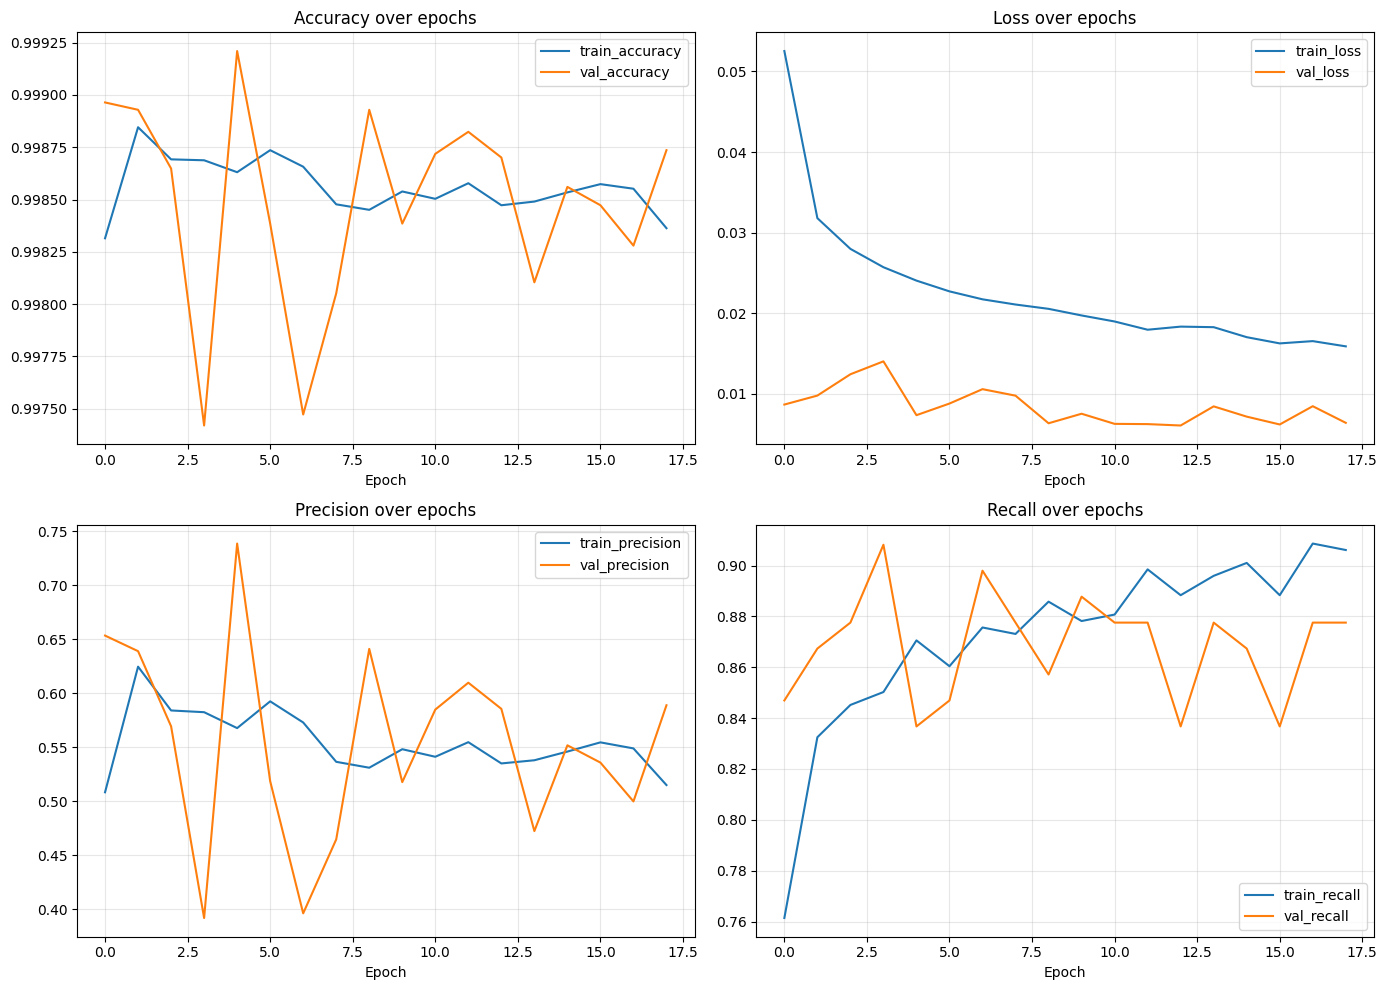

In [31]:
import matplotlib.pyplot as plt

metrics = ['accuracy', 'loss', 'precision', 'recall']

plt.figure(figsize=(14, 10))
for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    plt.plot(history_cost.history[metric], label=f'train_{metric}')
    plt.plot(history_cost.history[f'val_{metric}'], label=f'val_{metric}')
    plt.title(f'{metric.capitalize()} over epochs')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()